# 4. Dose-wise burst statistics with the frozen U-Net detector

This notebook applies the validation-frozen 1D U-Net burst detector to experimental single-cell trajectories and compares detected burst behavior across stimulation doses. It extracts burst frequency, width, height and center-to-center spacing.

The analysis uses only the experimental `test` fold. This matters because the synthetic detector's background archetypes were fitted from 100-pM training trajectories. Model weights, preprocessing, threshold and event post-processing are loaded without adaptation.

## Measurement definitions

- **Frequency:** detected events per trajectory and the equivalent rate per 24 hours.
- **Width:** detected half-open interval duration multiplied by the five-minute sampling interval.
- **Height:** maximum raw signal inside the interval minus the median signal in the available 60-minute flanks immediately before and after it.
- **Spacing:** center-to-center distance between consecutive events in the same trajectory.

Width, height and spacing plots use one median value per trajectory, preventing cells with many events from dominating the dose comparison. Event-level data remains available in `events`.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from deeplearning_examples.io import load_data
from burst_detection.artifacts import load_holdout_manifest, preprocessor_from_checkpoint
from burst_detection.data import mask_to_events
from burst_detection.metrics import probabilities_to_mask
from burst_detection.training import artifact_root, load_checkpoint, predict_probabilities

SAMPLE_INTERVAL_MINUTES = 5.0
MINIMUM_DURATION = 3
BRIDGE_GAP = 1
FLANK_SAMPLES = 12
RANDOM_SEED = 43
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
display(Markdown(f"**Inference device:** `{device}`."))

**Inference device:** `cuda`.

## 1. Restore the frozen U-Net protocol

The manifest provides the validation-selected operating threshold. The checkpoint provides architecture weights and train-fitted raw/derivative normalization. Metadata checks prevent accidental use of another detector.

In [2]:
manifest_path = artifact_root() / "unet_holdout_models.json"
if not manifest_path.is_file():
    raise FileNotFoundError("Run 02_unet_training_and_evaluation.ipynb first.")
manifest = load_holdout_manifest(manifest_path)
unet_candidates = [candidate for candidate in manifest["candidates"] if candidate["architecture"] == "unet"]
if len(unet_candidates) != 1:
    raise ValueError("Expected exactly one frozen U-Net candidate.")
candidate = unet_candidates[0]
checkpoint_path = artifact_root() / candidate["checkpoint"]
model, checkpoint = load_checkpoint(checkpoint_path, device=device)
if checkpoint["model_name"] != candidate["model_name"]:
    raise ValueError("Checkpoint and manifest model names differ.")
threshold = float(candidate["threshold"])
preprocessor = preprocessor_from_checkpoint(checkpoint)
protocol = pd.Series({
    "checkpoint": checkpoint_path.name,
    "best epoch": candidate["best_epoch"],
    "validation event F1": candidate["validation_metrics"]["event_f1"],
    "threshold": threshold,
    "minimum duration [samples]": MINIMUM_DURATION,
    "bridge gap [samples]": BRIDGE_GAP,
}, name="frozen U-Net protocol")
protocol.to_frame()

,frozen U-Net protocol
checkpoint,best_unet.pt
best epoch,34
validation event F1,0.975937
threshold,0.6
minimum duration [samples],3
bridge gap [samples],1


## 2. Experimental test trajectories and inference

In [3]:
trajectories, doses, years = load_data("test")
dose_order = sorted(np.unique(doses), key=lambda value: float(str(value).removesuffix("pM")))
features = preprocessor.transform(trajectories)
probabilities = predict_probabilities(model, features, device=device)
masks = probabilities_to_mask(
    probabilities, threshold=threshold,
    minimum_duration=MINIMUM_DURATION, bridge_gap=BRIDGE_GAP,
)
observation_hours = (trajectories.shape[1] - 1) * SAMPLE_INTERVAL_MINUTES / 60.0
display(Markdown(
    f"Analyzed **{len(trajectories)} held-out trajectories** with "
    f"**{trajectories.shape[1]} time points** ({observation_hours:.1f} hours each) "
    f"across **{len(dose_order)} doses**."
))

Analyzed **349 held-out trajectories** with **289 time points** (24.0 hours each) across **6 doses**.

## 3. Extract event- and trajectory-level measurements

Local flanks exclude the detected interval. At trajectory boundaries, height uses whichever flank is available. A trajectory without a detected event has zero frequency and missing width, height and spacing rather than an invented zero-sized burst.

In [4]:
def local_baseline(signal, start, stop, flank_samples=FLANK_SAMPLES):
    left = signal[max(0, start - flank_samples):start]
    right = signal[stop:min(len(signal), stop + flank_samples)]
    available = [values for values in (left, right) if len(values)]
    return float(np.median(np.concatenate(available))) if available else float(np.median(signal))


event_rows = []
trajectory_rows = []
for trajectory_id, (signal, probability, mask, dose, year) in enumerate(
    zip(trajectories, probabilities, masks, doses, years)
):
    detected = mask_to_events(mask)
    centers = np.asarray([event.center * SAMPLE_INTERVAL_MINUTES for event in detected])
    spacings = np.diff(centers)
    trajectory_rows.append({
        "trajectory_id": trajectory_id, "dose": str(dose), "year": int(year),
        "burst_count": len(detected),
        "bursts_per_24h": len(detected) * 24.0 / observation_hours,
        "median_spacing_minutes": float(np.median(spacings)) if len(spacings) else np.nan,
    })
    for event_index, event in enumerate(detected):
        segment = signal[event.start:event.stop]
        baseline = local_baseline(signal, event.start, event.stop)
        event_rows.append({
            "trajectory_id": trajectory_id, "event_index": event_index,
            "dose": str(dose), "year": int(year),
            "start_minutes": event.start * SAMPLE_INTERVAL_MINUTES,
            "stop_minutes": event.stop * SAMPLE_INTERVAL_MINUTES,
            "center_minutes": event.center * SAMPLE_INTERVAL_MINUTES,
            "width_minutes": event.duration * SAMPLE_INTERVAL_MINUTES,
            "height": float(segment.max() - baseline),
            "baseline": baseline,
            "peak_signal": float(segment.max()),
            "mean_probability": float(probability[event.start:event.stop].mean()),
            "max_probability": float(probability[event.start:event.stop].max()),
            "spacing_from_previous_minutes": (
                float(centers[event_index] - centers[event_index - 1])
                if event_index > 0 else np.nan
            ),
        })
events = pd.DataFrame(event_rows)
trajectory_stats = pd.DataFrame(trajectory_rows)
if events.empty:
    raise RuntimeError("The frozen U-Net detected no events in the test fold.")
event_medians = events.groupby("trajectory_id").agg(
    median_width_minutes=("width_minutes", "median"),
    median_height=("height", "median"),
).reset_index()
trajectory_stats = trajectory_stats.merge(event_medians, on="trajectory_id", how="left")
events.head()

,trajectory_id,event_index,dose,year,start_minutes,stop_minutes,center_minutes,width_minutes,height,baseline,peak_signal,mean_probability,max_probability,spacing_from_previous_minutes
0,0,0,1pM,2014,25.0,50.0,35.0,25.0,0.114741,0.385408,0.500149,0.748899,0.801943,NaN
1,0,1,1pM,2014,100.0,265.0,180.0,165.0,0.187025,0.366158,0.553183,0.953216,0.999712,145.0
2,0,2,1pM,2014,515.0,600.0,555.0,85.0,0.217027,0.380317,0.597344,0.976263,0.999952,375.0
3,0,3,1pM,2014,780.0,940.0,857.5,160.0,0.090963,0.380468,0.471431,0.859658,0.916209,302.5
4,0,4,1pM,2014,1205.0,1370.0,1285.0,165.0,0.132036,0.338749,0.470785,0.960418,0.999113,427.5


## 4. Dose-wise statistics

Counts include every held-out trajectory. Width and height summaries use per-trajectory medians among cells with at least one detected event; spacing requires at least two. IQR columns make the within-dose spread explicit.

In [5]:
def q25(values): return values.quantile(0.25)
def q75(values): return values.quantile(0.75)

dose_summary = trajectory_stats.groupby("dose", observed=True).agg(
    trajectories=("trajectory_id", "size"),
    total_bursts=("burst_count", "sum"),
    mean_bursts_per_cell=("burst_count", "mean"),
    median_bursts_per_cell=("burst_count", "median"),
    zero_burst_fraction=("burst_count", lambda values: np.mean(values == 0)),
    median_width_minutes=("median_width_minutes", "median"),
    width_q25=("median_width_minutes", q25),
    width_q75=("median_width_minutes", q75),
    median_height=("median_height", "median"),
    height_q25=("median_height", q25),
    height_q75=("median_height", q75),
    median_spacing_minutes=("median_spacing_minutes", "median"),
    spacing_q25=("median_spacing_minutes", q25),
    spacing_q75=("median_spacing_minutes", q75),
).reindex(dose_order)
dose_summary.round(3)

,trajectories,total_bursts,mean_bursts_per_cell,median_bursts_per_cell,zero_burst_fraction,median_width_minutes,width_q25,width_q75,median_height,height_q25,height_q75,median_spacing_minutes,spacing_q25,spacing_q75
dose,,,,,,,,,,,,,,
0pM,36,73,2.028,2.0,0.139,145.00,125.00,175.000,0.118,0.090,0.139,405.00,323.750,588.750
1pM,78,186,2.385,2.0,0.038,145.00,95.00,165.000,0.133,0.104,0.167,387.50,264.375,500.312
2.5pM,66,211,3.197,3.0,0.000,136.25,106.25,161.875,0.270,0.146,0.459,320.00,239.375,506.250
5pM,62,220,3.548,4.0,0.000,143.75,110.00,161.875,0.237,0.159,0.375,292.50,214.375,408.750
25pM,72,305,4.236,4.0,0.000,148.75,118.75,170.000,0.287,0.198,0.398,253.75,207.500,310.000
100pM,35,162,4.629,4.0,0.000,150.00,131.25,165.000,0.277,0.195,0.337,270.00,226.250,420.625


## 5. Frequency, width, height and spacing distributions

Each point is one trajectory. Jitter is deterministic and only separates overlapping points visually. Missing spacing values correspond to trajectories with fewer than two detected bursts.

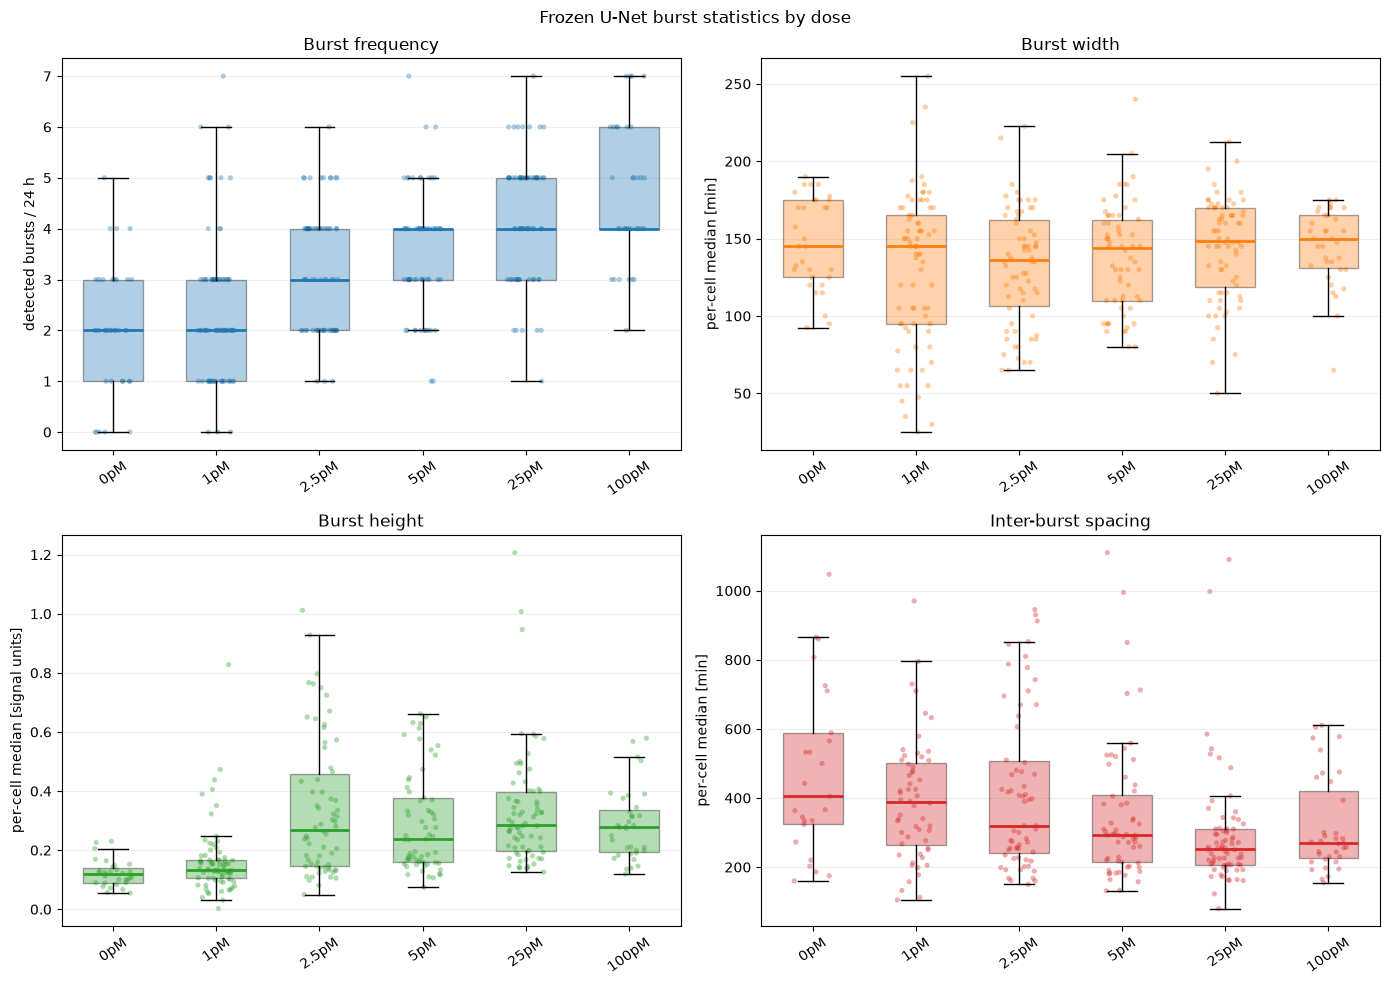

In [6]:
def dose_boxplot(axis, frame, column, title, ylabel, color):
    grouped = [frame.loc[frame.dose == dose, column].dropna().to_numpy() for dose in dose_order]
    positions = np.arange(len(dose_order))
    axis.boxplot(
        grouped, positions=positions, widths=0.58, patch_artist=True, showfliers=False,
        boxprops={"facecolor": color, "alpha": 0.35},
        medianprops={"color": color, "linewidth": 2},
    )
    rng = np.random.default_rng(RANDOM_SEED)
    for position, values in zip(positions, grouped):
        axis.scatter(
            position + rng.uniform(-0.18, 0.18, len(values)), values,
            s=14, alpha=0.38, color=color, edgecolors="none",
        )
    axis.set(title=title, ylabel=ylabel)
    axis.set_xticks(positions, dose_order, rotation=35)
    axis.grid(axis="y", alpha=0.2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
dose_boxplot(axes[0, 0], trajectory_stats, "bursts_per_24h", "Burst frequency", "detected bursts / 24 h", "tab:blue")
dose_boxplot(axes[0, 1], trajectory_stats, "median_width_minutes", "Burst width", "per-cell median [min]", "tab:orange")
dose_boxplot(axes[1, 0], trajectory_stats, "median_height", "Burst height", "per-cell median [signal units]", "tab:green")
dose_boxplot(axes[1, 1], trajectory_stats, "median_spacing_minutes", "Inter-burst spacing", "per-cell median [min]", "tab:red")
fig.suptitle("Frozen U-Net burst statistics by dose")
fig.tight_layout()

## 6. Burst timing across the experiment

Center-time histograms reveal whether dose differences reflect uniformly higher activity or bursts concentrated in particular phases. Counts are normalized within dose so unequal cell counts do not dominate the comparison.

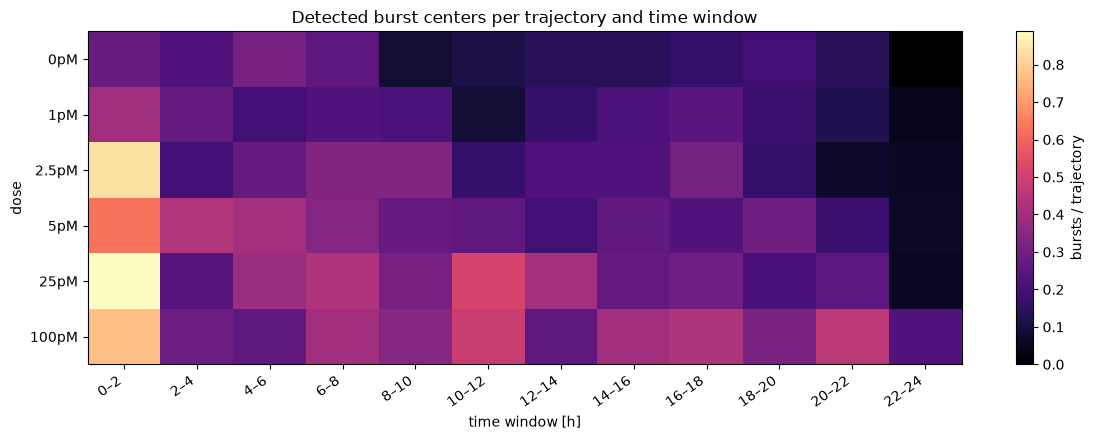

In [7]:
time_edges_minutes = np.linspace(0, trajectories.shape[1] * SAMPLE_INTERVAL_MINUTES, 13)
timing_rows = []
for dose in dose_order:
    centers = events.loc[events.dose == dose, "center_minutes"].to_numpy()
    counts, _ = np.histogram(centers, bins=time_edges_minutes)
    trajectory_count = int(np.sum(doses == dose))
    timing_rows.append(counts / trajectory_count)
timing = np.asarray(timing_rows)
fig, axis = plt.subplots(figsize=(12, 4.5))
image = axis.imshow(timing, aspect="auto", cmap="magma")
axis.set_yticks(range(len(dose_order)), dose_order)
axis.set_xticks(
    np.arange(len(time_edges_minutes) - 1),
    [f"{left/60:.0f}–{right/60:.0f}" for left, right in zip(time_edges_minutes[:-1], time_edges_minutes[1:])],
    rotation=35, ha="right",
)
axis.set(xlabel="time window [h]", ylabel="dose", title="Detected burst centers per trajectory and time window")
fig.colorbar(image, ax=axis, label="bursts / trajectory")
fig.tight_layout()

## 7. Representative detections for every dose

For each dose, the displayed trajectory has the closest burst count to that dose's median. Orange shading marks post-processed events, and the blue curve is the pointwise U-Net probability on a separate axis.

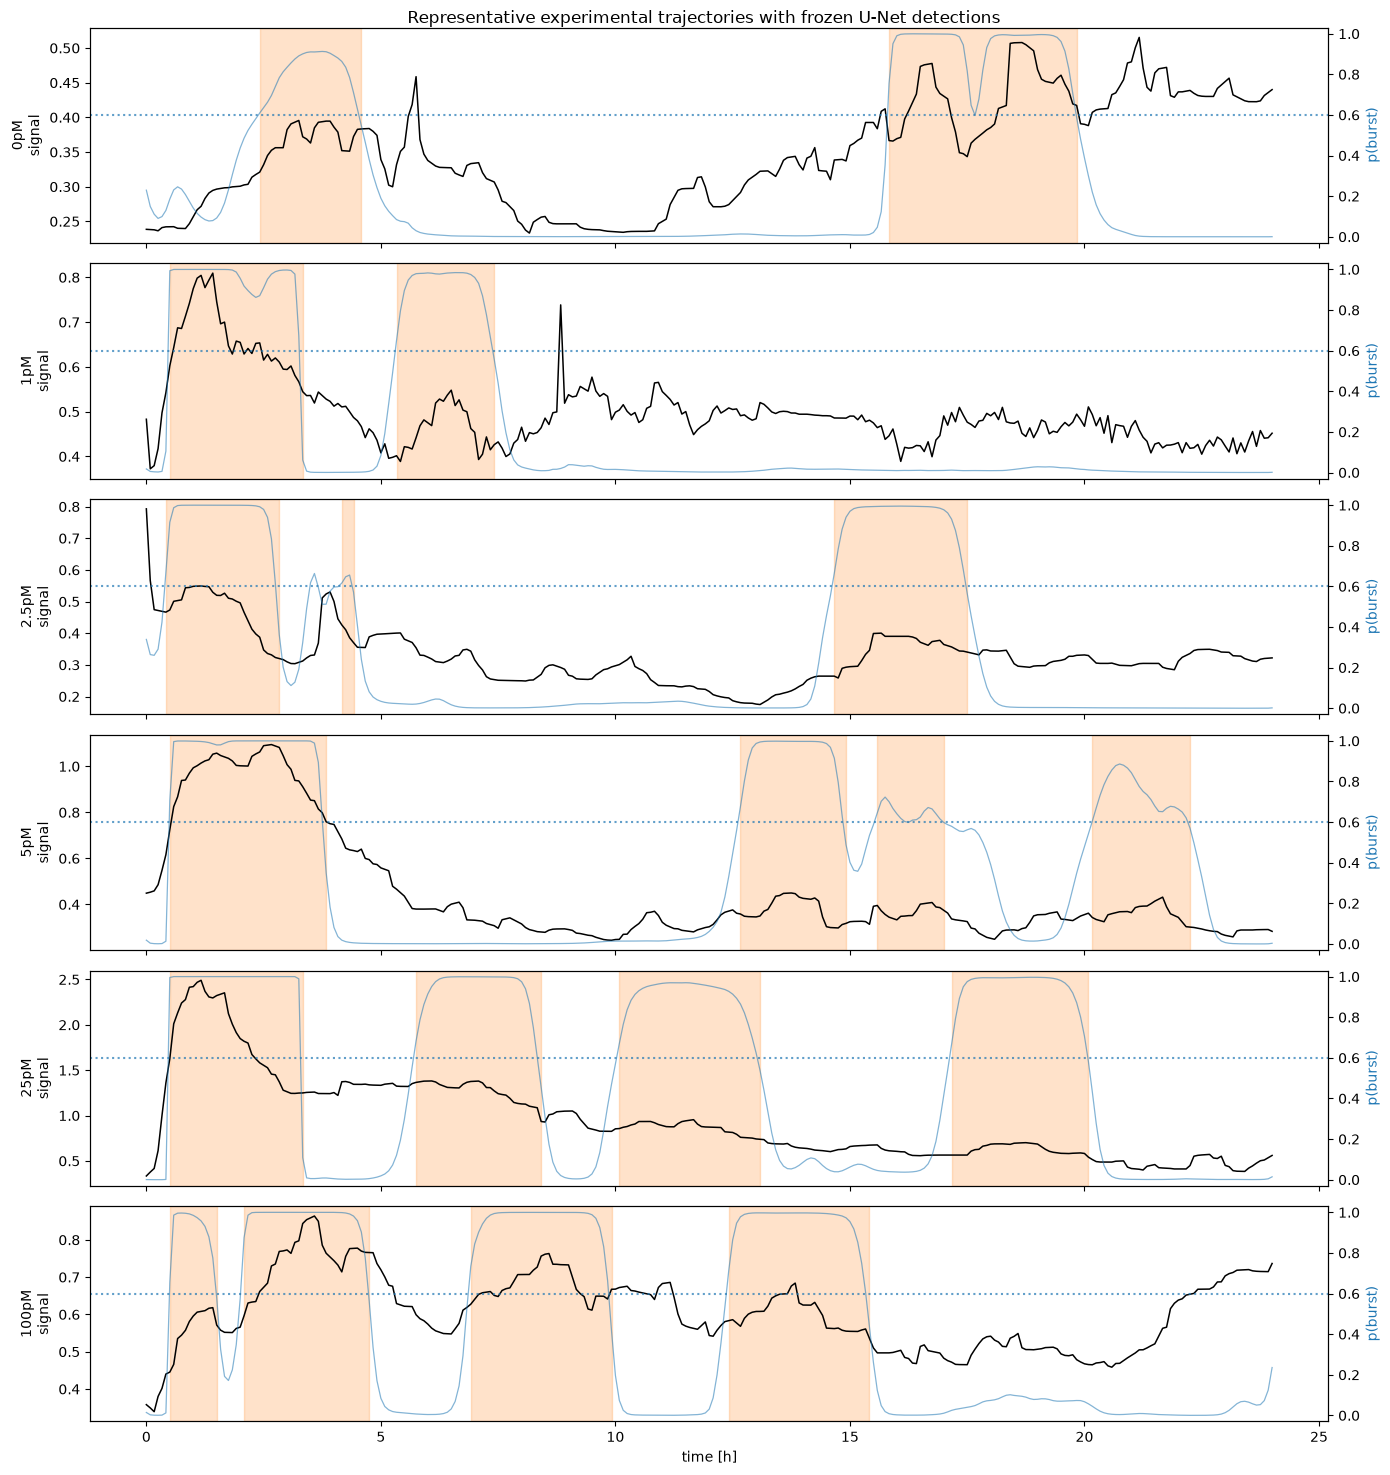

In [8]:
time_hours = np.arange(trajectories.shape[1]) * SAMPLE_INTERVAL_MINUTES / 60.0
fig, axes = plt.subplots(len(dose_order), 1, figsize=(14, 15), sharex=True)
for axis, dose in zip(axes, dose_order):
    candidates = trajectory_stats.loc[trajectory_stats.dose == dose]
    target_count = candidates["burst_count"].median()
    trajectory_id = int((candidates["burst_count"] - target_count).abs().idxmin())
    axis.plot(time_hours, trajectories[trajectory_id], color="black", linewidth=1.1, label="signal")
    for event in mask_to_events(masks[trajectory_id]):
        axis.axvspan(
            event.start * SAMPLE_INTERVAL_MINUTES / 60.0,
            event.stop * SAMPLE_INTERVAL_MINUTES / 60.0,
            color="tab:orange", alpha=0.22,
        )
    probability_axis = axis.twinx()
    probability_axis.plot(time_hours, probabilities[trajectory_id], color="tab:blue", alpha=0.55, linewidth=0.9)
    probability_axis.axhline(threshold, color="tab:blue", linestyle=":", alpha=0.7)
    probability_axis.set_ylim(-0.03, 1.03)
    probability_axis.set_ylabel("p(burst)", color="tab:blue")
    axis.set_ylabel(f"{dose}\nsignal")
axes[-1].set_xlabel("time [h]")
fig.suptitle("Representative experimental trajectories with frozen U-Net detections")
fig.tight_layout()

## 8. Result-specific interpretation

The frozen U-Net detects 1157 bursts in 349 held-out cells. The highest mean frequency occurs at 100pM (4.63 bursts/cell); the zero-burst fraction there is 0.0%.

The largest dose-level median width occurs at 100pM (150.0 min), and the largest median baseline-adjusted height at 25pM (0.287 signal units). Among cells with repeated bursts, 0pM has the longest dose-level median spacing (405.0 min).

26.3% of all detected events are centered before 200 min. This value, together with the timing heatmap, shows how strongly the detector's event totals are influenced by the initial response region. 1.8% have a non-positive baseline-adjusted height; these intervals are a concrete quality warning rather than being silently clipped to zero.

## Limitations

These are **model-detected events, not manually validated biological bursts**. The U-Net was selected on synthetic labels and the synthetic protocol explicitly labels the initial stimulus response as an event. Consequently, dose differences may combine true burst biology, dose-dependent baseline morphology and domain shift. The per-dose distributions and representative overlays should be reviewed before inferential testing. A confirmatory analysis needs manually annotated experimental trajectories or an annotation-blinded validation subset.